In [11]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [30]:
# define state 

class BMIState(TypedDict):
    weight: float   
    height: float
    bmi: float  
    category: str

In [32]:
# function calculate bmi

def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight']
    height = state['height']
    bmi = weight/(height**2)

    state['bmi']=round(bmi, 2)
    
    return state

def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = "under weight"
    if 18.5 <= bmi < 25 :
        state['category'] = "Normal"
    elif 25 <= bmi < 30:
        state['category'] = "Overweight"
    elif bmi >= 30:
        state['category'] = "Obese"
    return state

In [33]:
# define graph 
graph = StateGraph(BMIState)

# add nodes to the graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)


# add edges to the graph 
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile the graph
workflow = graph.compile()

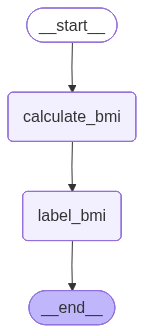

In [34]:
workflow

In [35]:
# execute or invoke the graph

initial_state = {'weight':70, 'height':1.67}

final_state = workflow.invoke(initial_state)

final_state

{'weight': 70, 'height': 1.67, 'bmi': 25.1, 'category': 'Overweight'}

### agent calling 

In [44]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict

from dotenv import load_dotenv
load_dotenv()

True

In [38]:
model = ChatGroq(model="llama-3.1-8b-instant")


In [43]:
# define state 

class LLMState(TypedDict):
    question: str
    answer: str

In [42]:
# node 

def groq_call(state: LLMState) -> LLMState:

    # extract question from the state 
    question = state['question'] 

    # form a prompt 
    prompt = f"answer the following question: {question}"

    # ask the question to model 
    answer = model.invoke(prompt)

    # return the response to state
    state['answer'] = answer
    return state

In [45]:
# define graph 
graph = StateGraph(LLMState)

# define node
graph.add_node('groq_call', groq_call)

# define edge 
graph.add_edge(START, 'groq_call')
graph.add_edge('groq_call', END)

# compile
workflow = graph.compile()

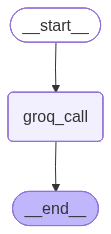

In [46]:
workflow

In [47]:
inital_state = {"question": f"tell about langgraph"}

final_state = workflow.invoke(inital_state)
final_state

{'question': 'tell about langgraph',
 'answer': AIMessage(content='LangGraph is a Python library for natural language processing (NLP) tasks, specifically designed for graph-based modeling and analysis of linguistic structures. It provides a comprehensive set of tools for representing and manipulating linguistic graphs, which are graphical representations of language relationships and structures.\n\nKey Features of LangGraph:\n\n1. **Linguistic Graph Representation**: LangGraph allows users to create and manipulate linguistic graphs using a variety of data structures and algorithms. These graphs can represent linguistic structures such as dependency trees, constituency trees, semantic graphs, and more.\n2. **Graph Algorithms**: The library includes a range of graph algorithms, such as graph traversal, clustering, and community detection, which can be applied to linguistic graphs for analysis and visualization.\n3. **Natural Language Processing (NLP) Integration**: LangGraph is designed

### chaining workflow in sequence

In [50]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict

from dotenv import load_dotenv
load_dotenv()


True

In [51]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [57]:
# define state 
class  BlogState(TypedDict):
    title: str
    outline:str
    content:str

In [68]:
# create nodes 
def create_outline(state: BlogState) -> BlogState:

    # title of blog 
    title = state['title']

    # outline prompt 
    outline_prompt = f"""Generate a detailed outline for a blog on the topic {title}"""

    # model
    outline_response = model.invoke(outline_prompt) 

    # update state 
    state['outline'] = outline_response

    return state 

def create_content(state: BlogState) -> BlogState:
    
    # content 
    outline = state['outline']

    # content prompt 
    content_prompt = f"""write a blog for the outlined topic {outline} """

    # model 
    content_response = model.invoke(content_prompt)

    # update state 
    state['content'] = content_response

    return state    

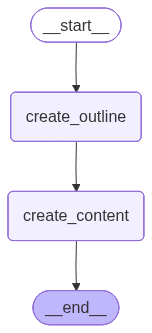

In [70]:
# state graph
graph = StateGraph(BlogState)

# nodes 
graph.add_node("create_outline", create_outline)
graph.add_node("create_content", create_content)

# edges
graph.add_edge(START, "create_outline")  
graph.add_edge("create_outline", "create_content")  
graph.add_edge("create_content", END) 

workflow = graph.compile()
workflow

In [71]:
initial_state = {"title":"python programming language"}

final_state = workflow.invoke(initial_state)

final_state

{'title': 'python programming language',
 'outline': AIMessage(content='**Title:** "Unlocking the Power of Python: A Comprehensive Guide to the Programming Language"\n\n**I. Introduction**\n\n* A brief overview of the Python programming language\n* History of Python and its evolution\n* Key features and benefits of using Python\n* Purpose of the blog post: to provide a comprehensive guide to Python programming for beginners and experienced developers\n\n**II. What is Python?**\n\n* Definition and history of Python\n* Key features of Python:\n\t+ Easy to learn and use\n\t+ High-level, interpreted language\n\t+ Object-oriented\n\t+ Cross-platform compatibility\n\t+ Large standard library\n\t+ Extensive community support\n* Comparison with other programming languages (e.g. Java, C++, JavaScript)\n\n**III. Setting Up Python**\n\n* Installing Python on different operating systems (Windows, macOS, Linux)\n* Choosing a Python IDE (Integrated Development Environment):\n\t+ PyCharm\n\t+ Visual 

In [73]:
print(final_state['outline'].content)

**Title:** "Unlocking the Power of Python: A Comprehensive Guide to the Programming Language"

**I. Introduction**

* A brief overview of the Python programming language
* History of Python and its evolution
* Key features and benefits of using Python
* Purpose of the blog post: to provide a comprehensive guide to Python programming for beginners and experienced developers

**II. What is Python?**

* Definition and history of Python
* Key features of Python:
	+ Easy to learn and use
	+ High-level, interpreted language
	+ Object-oriented
	+ Cross-platform compatibility
	+ Large standard library
	+ Extensive community support
* Comparison with other programming languages (e.g. Java, C++, JavaScript)

**III. Setting Up Python**

* Installing Python on different operating systems (Windows, macOS, Linux)
* Choosing a Python IDE (Integrated Development Environment):
	+ PyCharm
	+ Visual Studio Code
	+ Spyder
	+ IDLE
* Configuring Python for development:
	+ Setting up a virtual environment
	+